In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [10]:
# 1. Load data (label = ham/spam, message = text)
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep="\t", header=None, names=["label", "message"])
df["target"] = df["label"].map({"ham": 0, "spam": 1})
print(df.shape)
print(df["label"].value_counts())

(5572, 3)
label
ham     4825
spam     747
Name: count, dtype: int64


In [11]:
# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["target"], test_size=0.2, random_state=42, stratify=df["target"]
)

In [12]:
# 3. Build models (TF-IDF + classifier)
models = {
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", lowercase=True)),
        ("clf", MultinomialNB()),
    ]),
    "SVM": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", lowercase=True)),
        ("clf", LinearSVC()),
    ]),
}


===== Naive Bayes =====
Accuracy: 0.9704
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


===== SVM =====
Accuracy: 0.9839
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



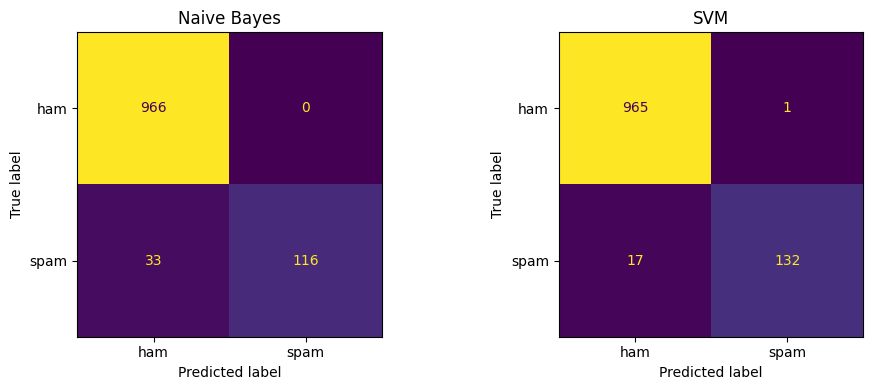

In [13]:
# 4. Train and evaluate
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n===== {name} =====")
    print("Accuracy:", round(accuracy_score(y_test, preds), 4))
    print(classification_report(y_test, preds, target_names=["ham", "spam"]))
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds), display_labels=["ham", "spam"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [14]:
# 5. Try your own messages
def predict_spam(text, model_name="SVM"):
    pred = models[model_name].predict([text])[0]
    return "SPAM" if pred == 1 else "NOT SPAM"

tests = [
    "Congratulations! You've won a $1000 gift card. Click here to claim now!",
    "Hey, are we still meeting for the project discussion tomorrow?",
    "URGENT: Your account is suspended. Verify your details immediately.",
]
for t in tests:
    print(f"\n{t}\n -> NB: {predict_spam(t, 'Naive Bayes')} | SVM: {predict_spam(t, 'SVM')}")



Congratulations! You've won a $1000 gift card. Click here to claim now!
 -> NB: SPAM | SVM: SPAM

Hey, are we still meeting for the project discussion tomorrow?
 -> NB: NOT SPAM | SVM: NOT SPAM

URGENT: Your account is suspended. Verify your details immediately.
 -> NB: SPAM | SVM: SPAM
